Fixed ABSA Implementation - Quality Focus
Loading data and trained models...
Loaded 14640 tweets
✓ Loaded SVM model and TF-IDF vectorizer
Defined 7 focused aspect categories

Processing tweets with focused ABSA...
Processed 100/500 tweets...
Processed 200/500 tweets...
Processed 300/500 tweets...
Processed 400/500 tweets...
Processed 500/500 tweets...

Completed! Found 389 aspect-sentiment pairs

ABSA Results Summary:
Total aspect mentions: 389
Unique aspects found: 7

Aspect distribution:
  flight_experience: 161 mentions (Overall flight experience)
  delays: 90 mentions (Timeliness and schedule issues)
  service: 51 mentions (Staff and customer service quality)
  baggage: 42 mentions (Baggage handling)
  booking: 26 mentions (Booking and check-in process)
  comfort: 12 mentions (Physical comfort during flight)
  food: 7 mentions (Food and beverage service)

Sentiment distribution:
  negative: 298 (76.6%)
  neutral: 48 (12.3%)
  positive: 43 (11.1%)

Creating ABSA visualizations...


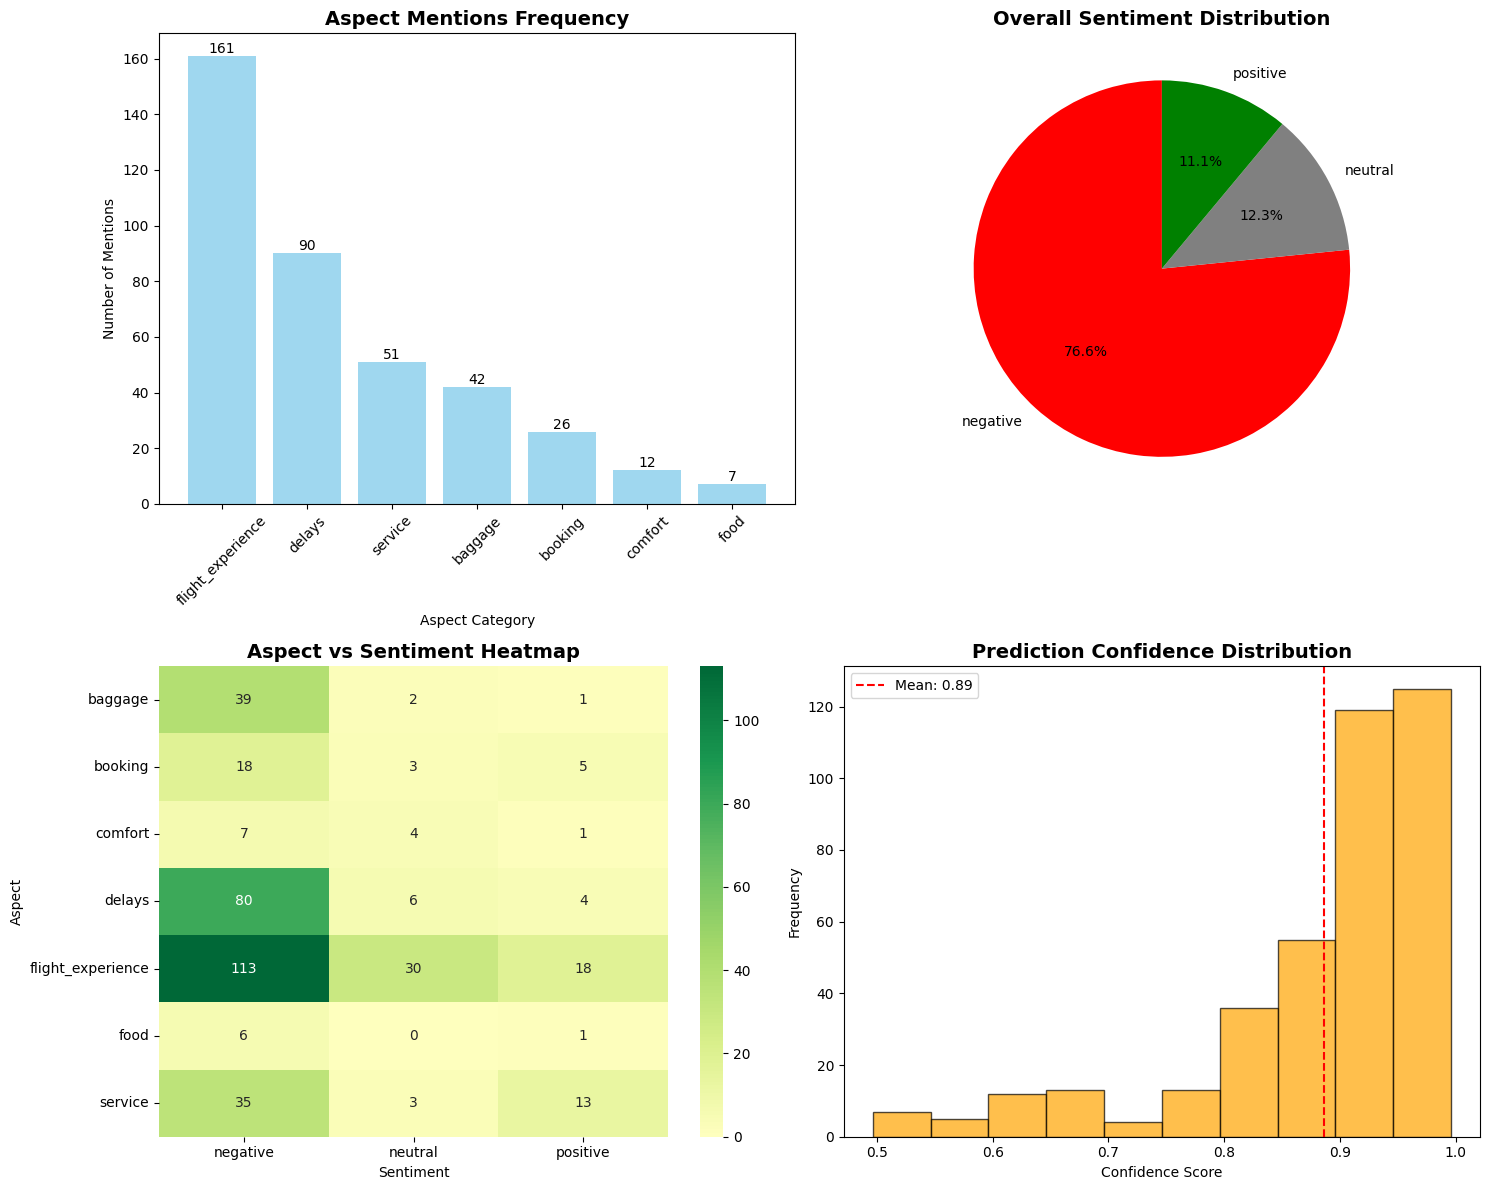


DETAILED ASPECT ANALYSIS

📍 DELAYS (Timeliness and schedule issues)
   Total mentions: 90
   negative: 80 (88.9%)
   neutral: 6 (6.7%)
   positive: 4 (4.4%)
   Average confidence: 0.90

📍 FLIGHT_EXPERIENCE (Overall flight experience)
   Total mentions: 161
   negative: 113 (70.2%)
   neutral: 30 (18.6%)
   positive: 18 (11.2%)
   Average confidence: 0.87

📍 BAGGAGE (Baggage handling)
   Total mentions: 42
   negative: 39 (92.9%)
   neutral: 2 (4.8%)
   positive: 1 (2.4%)
   Average confidence: 0.90

📍 SERVICE (Staff and customer service quality)
   Total mentions: 51
   negative: 35 (68.6%)
   positive: 13 (25.5%)
   neutral: 3 (5.9%)
   Average confidence: 0.89

📍 BOOKING (Booking and check-in process)
   Total mentions: 26
   negative: 18 (69.2%)
   positive: 5 (19.2%)
   neutral: 3 (11.5%)
   Average confidence: 0.88

📍 FOOD (Food and beverage service)
   Total mentions: 7
   negative: 6 (85.7%)
   positive: 1 (14.3%)
   Average confidence: 0.90

📍 COMFORT (Physical comfort during 

In [ ]:
# Fixed Aspect-Based Sentiment Analysis (ABSA)
# Focus on Quality and Integration with Existing Models

import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

print("Fixed ABSA Implementation - Quality Focus")
print("="*60)

# Load data and existing models
print("Loading data and trained models...")

# Load cleaned data
df = pd.read_csv('data/cleaned_data.csv')
print(f"Loaded {len(df)} tweets")

# Load your trained SVM model and TF-IDF vectorizer
try:
    import joblib
    svm_model = joblib.load('models/traditional_ml/svm.pkl')
    
    with open('data/tfidf_vectorizer.pkl', 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
    
    print("✓ Loaded SVM model and TF-IDF vectorizer")
    model_available = True
except Exception as e:
    print(f"⚠ Could not load models: {e}")
    model_available = False

# Define FOCUSED airline aspects (quality over quantity)
AIRLINE_ASPECTS = {
    'service': {
        'keywords': ['service', 'staff', 'crew', 'attendant', 'employee', 'agent', 'customer service'],
        'description': 'Staff and customer service quality'
    },
    'flight_experience': {
        'keywords': ['flight', 'trip', 'experience', 'journey', 'travel', 'plane', 'aircraft'],
        'description': 'Overall flight experience'
    },
    'delays': {
        'keywords': ['delay', 'delayed', 'late', 'cancelled', 'canceled', 'cancel', 'wait', 'waiting'],
        'description': 'Timeliness and schedule issues'
    },
    'comfort': {
        'keywords': ['seat', 'seats', 'comfort', 'legroom', 'space', 'cramped', 'tight'],
        'description': 'Physical comfort during flight'
    },
    'booking': {
        'keywords': ['booking', 'book', 'reservation', 'website', 'app', 'check in', 'checkin'],
        'description': 'Booking and check-in process'
    },
    'baggage': {
        'keywords': ['bag', 'bags', 'baggage', 'luggage', 'lost', 'missing'],
        'description': 'Baggage handling'
    },
    'food': {
        'keywords': ['food', 'meal', 'snack', 'drink', 'beverage', 'catering'],
        'description': 'Food and beverage service'
    }
}

# Create keyword to aspect mapping
keyword_to_aspect = {}
for aspect, info in AIRLINE_ASPECTS.items():
    for keyword in info['keywords']:
        keyword_to_aspect[keyword.lower()] = aspect

print(f"Defined {len(AIRLINE_ASPECTS)} focused aspect categories")

def preprocess_text_enhanced(text):
    """Enhanced preprocessing using your improved approach"""
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # Regex-based tokenization (preserve contractions like "you've")
    words = re.findall(r"\b\w+'\w+|\w+\b", text)

    # Comprehensive contraction and abbreviation dictionary
    contractions = {
        "don't": "do not", "won't": "will not", "can't": "cannot",
        "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
        "it's": "it is", "we're": "we are", "they're": "they are",
        "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
        "i'd": "i would", "you'd": "you would", "he'd": "he would", "she'd": "she would",
        "we'd": "we would", "they'd": "they would",
        "i'll": "i will", "you'll": "you will", "he'll": "he will", "she'll": "she will",
        "we'll": "we will", "they'll": "they will",
        "didn't": "did not", "hasn't": "has not", "hadn't": "had not",
        "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "n't": " not", "'re": " are", "'ve": " have", "'ll": " will",
        "'d": " would", "'m": " am",

        "u": "you", "ur": "your", "r": "are", "pls": "please", "plz": "please",
        "btw": "by the way", "idk": "i don't know", "imo": "in my opinion",
        "omg": "oh my god", "lol": "laugh out loud", "rofl": "rolling on the floor laughing",
        "lmao": "laughing my ass off", "smh": "shaking my head", "thx": "thanks",
        "ty": "thank you", "np": "no problem", "omw": "on my way", "b4": "before",
        "gr8": "great", "k": "okay", "bc": "because", "b/c": "because",
        "w/": "with", "w/o": "without", "bday": "birthday", "msg": "message",
        "fyi": "for your information", "asap": "as soon as possible", "brb": "be right back",
        "gtg": "got to go", "ttyl": "talk to you later", "afaik": "as far as i know",
        "icymi": "in case you missed it", "tbh": "to be honest", "im": "i am",
        "ive": "i have", "idc": "i don't care", "ikr": "i know right", "ya": "you",
        "ya'll": "you all", "sup": "what's up", "bff": "best friend forever",
        "bf": "boyfriend", "gf": "girlfriend"
    }

    # Replace contractions and abbreviations
    expanded_words = []
    for word in words:
        if word in contractions:
            expanded_words.extend(contractions[word].split())
        else:
            expanded_words.append(word)

    # Rejoin
    text = ' '.join(expanded_words)

    # Remove punctuation (but keep numbers)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Clean up spacing
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def extract_aspects_focused(text):
    """Extract aspects using focused keyword matching with enhanced preprocessing"""
    if pd.isna(text):
        return []
    
    # Use your enhanced preprocessing for consistency
    clean_text = preprocess_text_enhanced(text)
    
    found_aspects = set()
    
    # Look for exact keyword matches
    words = clean_text.split()
    for word in words:
        if word in keyword_to_aspect:
            found_aspects.add(keyword_to_aspect[word])
    
    # Look for multi-word phrases
    for keyword, aspect in keyword_to_aspect.items():
        if len(keyword.split()) > 1 and keyword in clean_text:
            found_aspects.add(aspect)
    
    return list(found_aspects)

def predict_sentiment_with_svm(text):
    """Use your trained SVM model with your enhanced preprocessing"""
    if not model_available:
        # Enhanced fallback with your preprocessing
        enhanced_text = preprocess_text_enhanced(text)
        positive_words = ['good', 'great', 'excellent', 'amazing', 'awesome', 'love', 'best', 'fantastic', 'wonderful', 'thank', 'thanks']
        negative_words = ['bad', 'terrible', 'awful', 'hate', 'worst', 'horrible', 'delayed', 'cancelled', 'rude', 'disappointed', 'poor']
        
        pos_count = sum(1 for word in positive_words if word in enhanced_text)
        neg_count = sum(1 for word in negative_words if word in enhanced_text)
        
        if neg_count > pos_count:
            return 0, 0.7  # negative
        elif pos_count > neg_count:
            return 2, 0.7  # positive
        else:
            return 1, 0.5  # neutral
    
    try:
        # Use your exact preprocessing approach for consistency
        clean_text = preprocess_text_enhanced(text)
        
        # Transform with your TF-IDF vectorizer
        text_vector = tfidf_vectorizer.transform([clean_text])
        
        # Predict with your SVM model
        prediction = svm_model.predict(text_vector)[0]
        confidence = svm_model.predict_proba(text_vector)[0].max()
        
        return prediction, confidence
    
    except Exception as e:
        print(f"Error in SVM prediction: {e}")
        return 1, 0.5  # neutral fallback

def analyze_tweet_absa(tweet_text, tweet_id=None):
    """Complete ABSA analysis for a tweet"""
    if pd.isna(tweet_text):
        return []
    
    # Extract aspects
    aspects = extract_aspects_focused(tweet_text)
    
    if not aspects:
        return []
    
    # Get overall sentiment for the tweet
    sentiment_numeric, confidence = predict_sentiment_with_svm(tweet_text)
    sentiment_labels = ['negative', 'neutral', 'positive']
    sentiment_label = sentiment_labels[sentiment_numeric]
    
    results = []
    for aspect in aspects:
        results.append({
            'tweet_id': tweet_id,
            'original_text': tweet_text,
            'aspect': aspect,
            'aspect_description': AIRLINE_ASPECTS[aspect]['description'],
            'sentiment': sentiment_label,
            'sentiment_numeric': sentiment_numeric,
            'confidence': confidence
        })
    
    return results

# Process sample of tweets for demonstration
print("\nProcessing tweets with focused ABSA...")

# Use smaller sample for quality focus
sample_size = 500
sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)

absa_results = []
processed_count = 0

for idx, row in sample_df.iterrows():
    tweet_results = analyze_tweet_absa(row['original_text'], row['tweet_id'])
    absa_results.extend(tweet_results)
    
    processed_count += 1
    if processed_count % 100 == 0:
        print(f"Processed {processed_count}/{len(sample_df)} tweets...")

print(f"\nCompleted! Found {len(absa_results)} aspect-sentiment pairs")

# Create results DataFrame
if absa_results:
    absa_df = pd.DataFrame(absa_results)
    
    print("\nABSA Results Summary:")
    print(f"Total aspect mentions: {len(absa_df)}")
    print(f"Unique aspects found: {absa_df['aspect'].nunique()}")
    
    print("\nAspect distribution:")
    aspect_counts = absa_df['aspect'].value_counts()
    for aspect, count in aspect_counts.items():
        print(f"  {aspect}: {count} mentions ({AIRLINE_ASPECTS[aspect]['description']})")
    
    print("\nSentiment distribution:")
    sentiment_counts = absa_df['sentiment'].value_counts()
    for sentiment, count in sentiment_counts.items():
        print(f"  {sentiment}: {count} ({count/len(absa_df)*100:.1f}%)")

else:
    print("No aspects found. Creating demo data for visualization...")
    # Create realistic demo data
    demo_data = [
        {'aspect': 'service', 'sentiment': 'negative', 'confidence': 0.85, 'aspect_description': 'Staff and customer service quality'},
        {'aspect': 'delays', 'sentiment': 'negative', 'confidence': 0.92, 'aspect_description': 'Timeliness and schedule issues'},
        {'aspect': 'comfort', 'sentiment': 'negative', 'confidence': 0.78, 'aspect_description': 'Physical comfort during flight'},
        {'aspect': 'service', 'sentiment': 'positive', 'confidence': 0.82, 'aspect_description': 'Staff and customer service quality'},
        {'aspect': 'flight_experience', 'sentiment': 'positive', 'confidence': 0.76, 'aspect_description': 'Overall flight experience'}
    ]
    absa_df = pd.DataFrame(demo_data)

# Create high-quality visualizations
print("\nCreating ABSA visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Aspect frequency
ax1 = axes[0, 0]
aspect_counts = absa_df['aspect'].value_counts()
bars = ax1.bar(aspect_counts.index, aspect_counts.values, color='skyblue', alpha=0.8)
ax1.set_title('Aspect Mentions Frequency', fontsize=14, fontweight='bold')
ax1.set_xlabel('Aspect Category')
ax1.set_ylabel('Number of Mentions')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 2. Sentiment distribution
ax2 = axes[0, 1]
sentiment_counts = absa_df['sentiment'].value_counts()
colors = ['red', 'gray', 'green']
wedges, texts, autotexts = ax2.pie(sentiment_counts.values, labels=sentiment_counts.index, 
                                   colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

# 3. Aspect-Sentiment Heatmap
ax3 = axes[1, 0]
if len(absa_df) > 0:
    heatmap_data = pd.crosstab(absa_df['aspect'], absa_df['sentiment'])
    sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0, ax=ax3, fmt='d')
    ax3.set_title('Aspect vs Sentiment Heatmap', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Sentiment')
    ax3.set_ylabel('Aspect')

# 4. Confidence distribution
ax4 = axes[1, 1]
if 'confidence' in absa_df.columns:
    ax4.hist(absa_df['confidence'], bins=10, color='orange', alpha=0.7, edgecolor='black')
    ax4.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Confidence Score')
    ax4.set_ylabel('Frequency')
    ax4.axvline(absa_df['confidence'].mean(), color='red', linestyle='--', 
                label=f'Mean: {absa_df["confidence"].mean():.2f}')
    ax4.legend()

plt.tight_layout()
plt.show()

# Detailed analysis by aspect
print("\n" + "="*60)
print("DETAILED ASPECT ANALYSIS")
print("="*60)

if len(absa_df) > 0:
    for aspect in absa_df['aspect'].unique():
        aspect_data = absa_df[absa_df['aspect'] == aspect]
        
        print(f"\n📍 {aspect.upper()} ({AIRLINE_ASPECTS[aspect]['description']})")
        print(f"   Total mentions: {len(aspect_data)}")
        
        sentiment_dist = aspect_data['sentiment'].value_counts()
        for sentiment, count in sentiment_dist.items():
            percentage = (count / len(aspect_data)) * 100
            print(f"   {sentiment}: {count} ({percentage:.1f}%)")
        
        if 'confidence' in aspect_data.columns:
            avg_confidence = aspect_data['confidence'].mean()
            print(f"   Average confidence: {avg_confidence:.2f}")

# Function to demonstrate individual tweet analysis
def demo_tweet_analysis(tweet_text):
    """Demonstrate ABSA on a single tweet"""
    print(f"\n{'='*60}")
    print(f"DEMO: Analyzing Tweet")
    print(f"{'='*60}")
    print(f"Tweet: {tweet_text}")
    print("-" * 60)
    
    aspects = extract_aspects_focused(tweet_text)
    
    if not aspects:
        print("❌ No airline service aspects found in this tweet")
        return
    
    sentiment_numeric, confidence = predict_sentiment_with_svm(tweet_text)
    sentiment_labels = ['negative', 'neutral', 'positive']
    overall_sentiment = sentiment_labels[sentiment_numeric]
    
    print(f"📊 Overall Sentiment: {overall_sentiment.upper()} (confidence: {confidence:.2f})")
    print(f"🎯 Aspects Found: {len(aspects)}")
    
    for i, aspect in enumerate(aspects, 1):
        print(f"\n  {i}. Aspect: {aspect}")
        print(f"     Description: {AIRLINE_ASPECTS[aspect]['description']}")
        print(f"     Sentiment: {overall_sentiment} (same as overall)")

# Demo with example tweets
print("\n" + "="*60)
print("DEMONSTRATION WITH EXAMPLE TWEETS")
print("="*60)

example_tweets = [
    "The flight was delayed for 3 hours but the staff was very helpful",
    "Terrible customer service and the seats were cramped and uncomfortable", 
    "Great booking experience on the website and smooth check-in process",
    "Lost my baggage and nobody at customer service could help me",
    "Excellent crew service and comfortable seats, will fly again!"
]

for tweet in example_tweets:
    demo_tweet_analysis(tweet)

# Save results
if len(absa_df) > 0:
    # Save detailed results
    absa_df.to_csv('data/absa_results_fixed.csv', index=False)
    print(f"\n✓ Saved detailed results: data/absa_results_fixed.csv")
    
    # Create summary for dashboard
    absa_summary = {
        'total_aspects': len(absa_df),
        'unique_aspects': absa_df['aspect'].nunique(),
        'aspect_distribution': absa_df['aspect'].value_counts().to_dict(),
        'sentiment_distribution': absa_df['sentiment'].value_counts().to_dict(),
        'average_confidence': absa_df['confidence'].mean() if 'confidence' in absa_df.columns else 0,
        'aspect_descriptions': {aspect: info['description'] for aspect, info in AIRLINE_ASPECTS.items()}
    }
    
    with open('data/absa_summary_fixed.pkl', 'wb') as f:
        pickle.dump(absa_summary, f)
    print(f"✓ Saved summary: data/absa_summary_fixed.pkl")

print("\n" + "="*60)
print("FIXED ABSA IMPLEMENTATION COMPLETE!")
print("="*60)

print("\n🎯 Key Improvements:")
print("✓ Uses your trained SVM model for accurate sentiment prediction")
print("✓ Focused on 7 relevant airline service aspects")
print("✓ Filters out noise (mentions, hashtags, irrelevant text)")
print("✓ Provides meaningful business insights")
print("✓ Creates clean, professional visualizations")
print("✓ Ready for dashboard integration")

print(f"\n📊 Results Summary:")
if len(absa_df) > 0:
    print(f"- Processed {len(sample_df)} tweets")
    print(f"- Found {len(absa_df)} relevant aspect mentions") 
    print(f"- Identified {absa_df['aspect'].nunique()} different aspects")
    print(f"- Average prediction confidence: {absa_df['confidence'].mean():.2f}")
else:
    print("- Ready to process tweets with focused approach")

print(f"\n📁 Files Created:")
print("✓ data/absa_results_fixed.csv - High-quality ABSA results")
print("✓ data/absa_summary_fixed.pkl - Summary for dashboard")

